In [1]:
import scanpy as sc
import os
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math
import os
import pickle
from scipy.stats import linregress
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

import seaborn as sns



# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(5,5))
%matplotlib inline
sc.settings.verbosity = 0


In [2]:
adata_5k=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_xenium_v3.h5ad.final.timepointsforpaper')
def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata_5k.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata_5k.var_names]
    return LIST



In [3]:
def bin_response(x):
    return "Non-Responder" if x < 10 else "Responder" if x > 50 else np.nan

In [4]:
KEEP = ["Lesional Baseline", "Week 12" ]
adata_5k_baseline = adata_5k[adata_5k.obs["Timepoint2"].isin(KEEP)]
adata_5k_baseline = adata_5k_baseline[adata_5k_baseline.obs["disease_overall"]=="AD"]
valid_mask = ~adata_5k_baseline.obs["response"].isna()
adata_5k_baseline = adata_5k_baseline[valid_mask, :].copy()


In [5]:
RENAME = {"MigDC (cDC2)": "MigDC",
         "Treg_LRRC32+": "Treg"
         }
adata_5k_baseline.obs["lvl4_annotation"]=adata_5k_baseline.obs["lvl4_annotation"].map(RENAME).fillna(adata_5k_baseline.obs["lvl4_annotation"])
adata_5k_baseline = adata_5k_baseline [ adata_5k_baseline.obs["lvl4_annotation"]!="MigDC (cDC1)"]

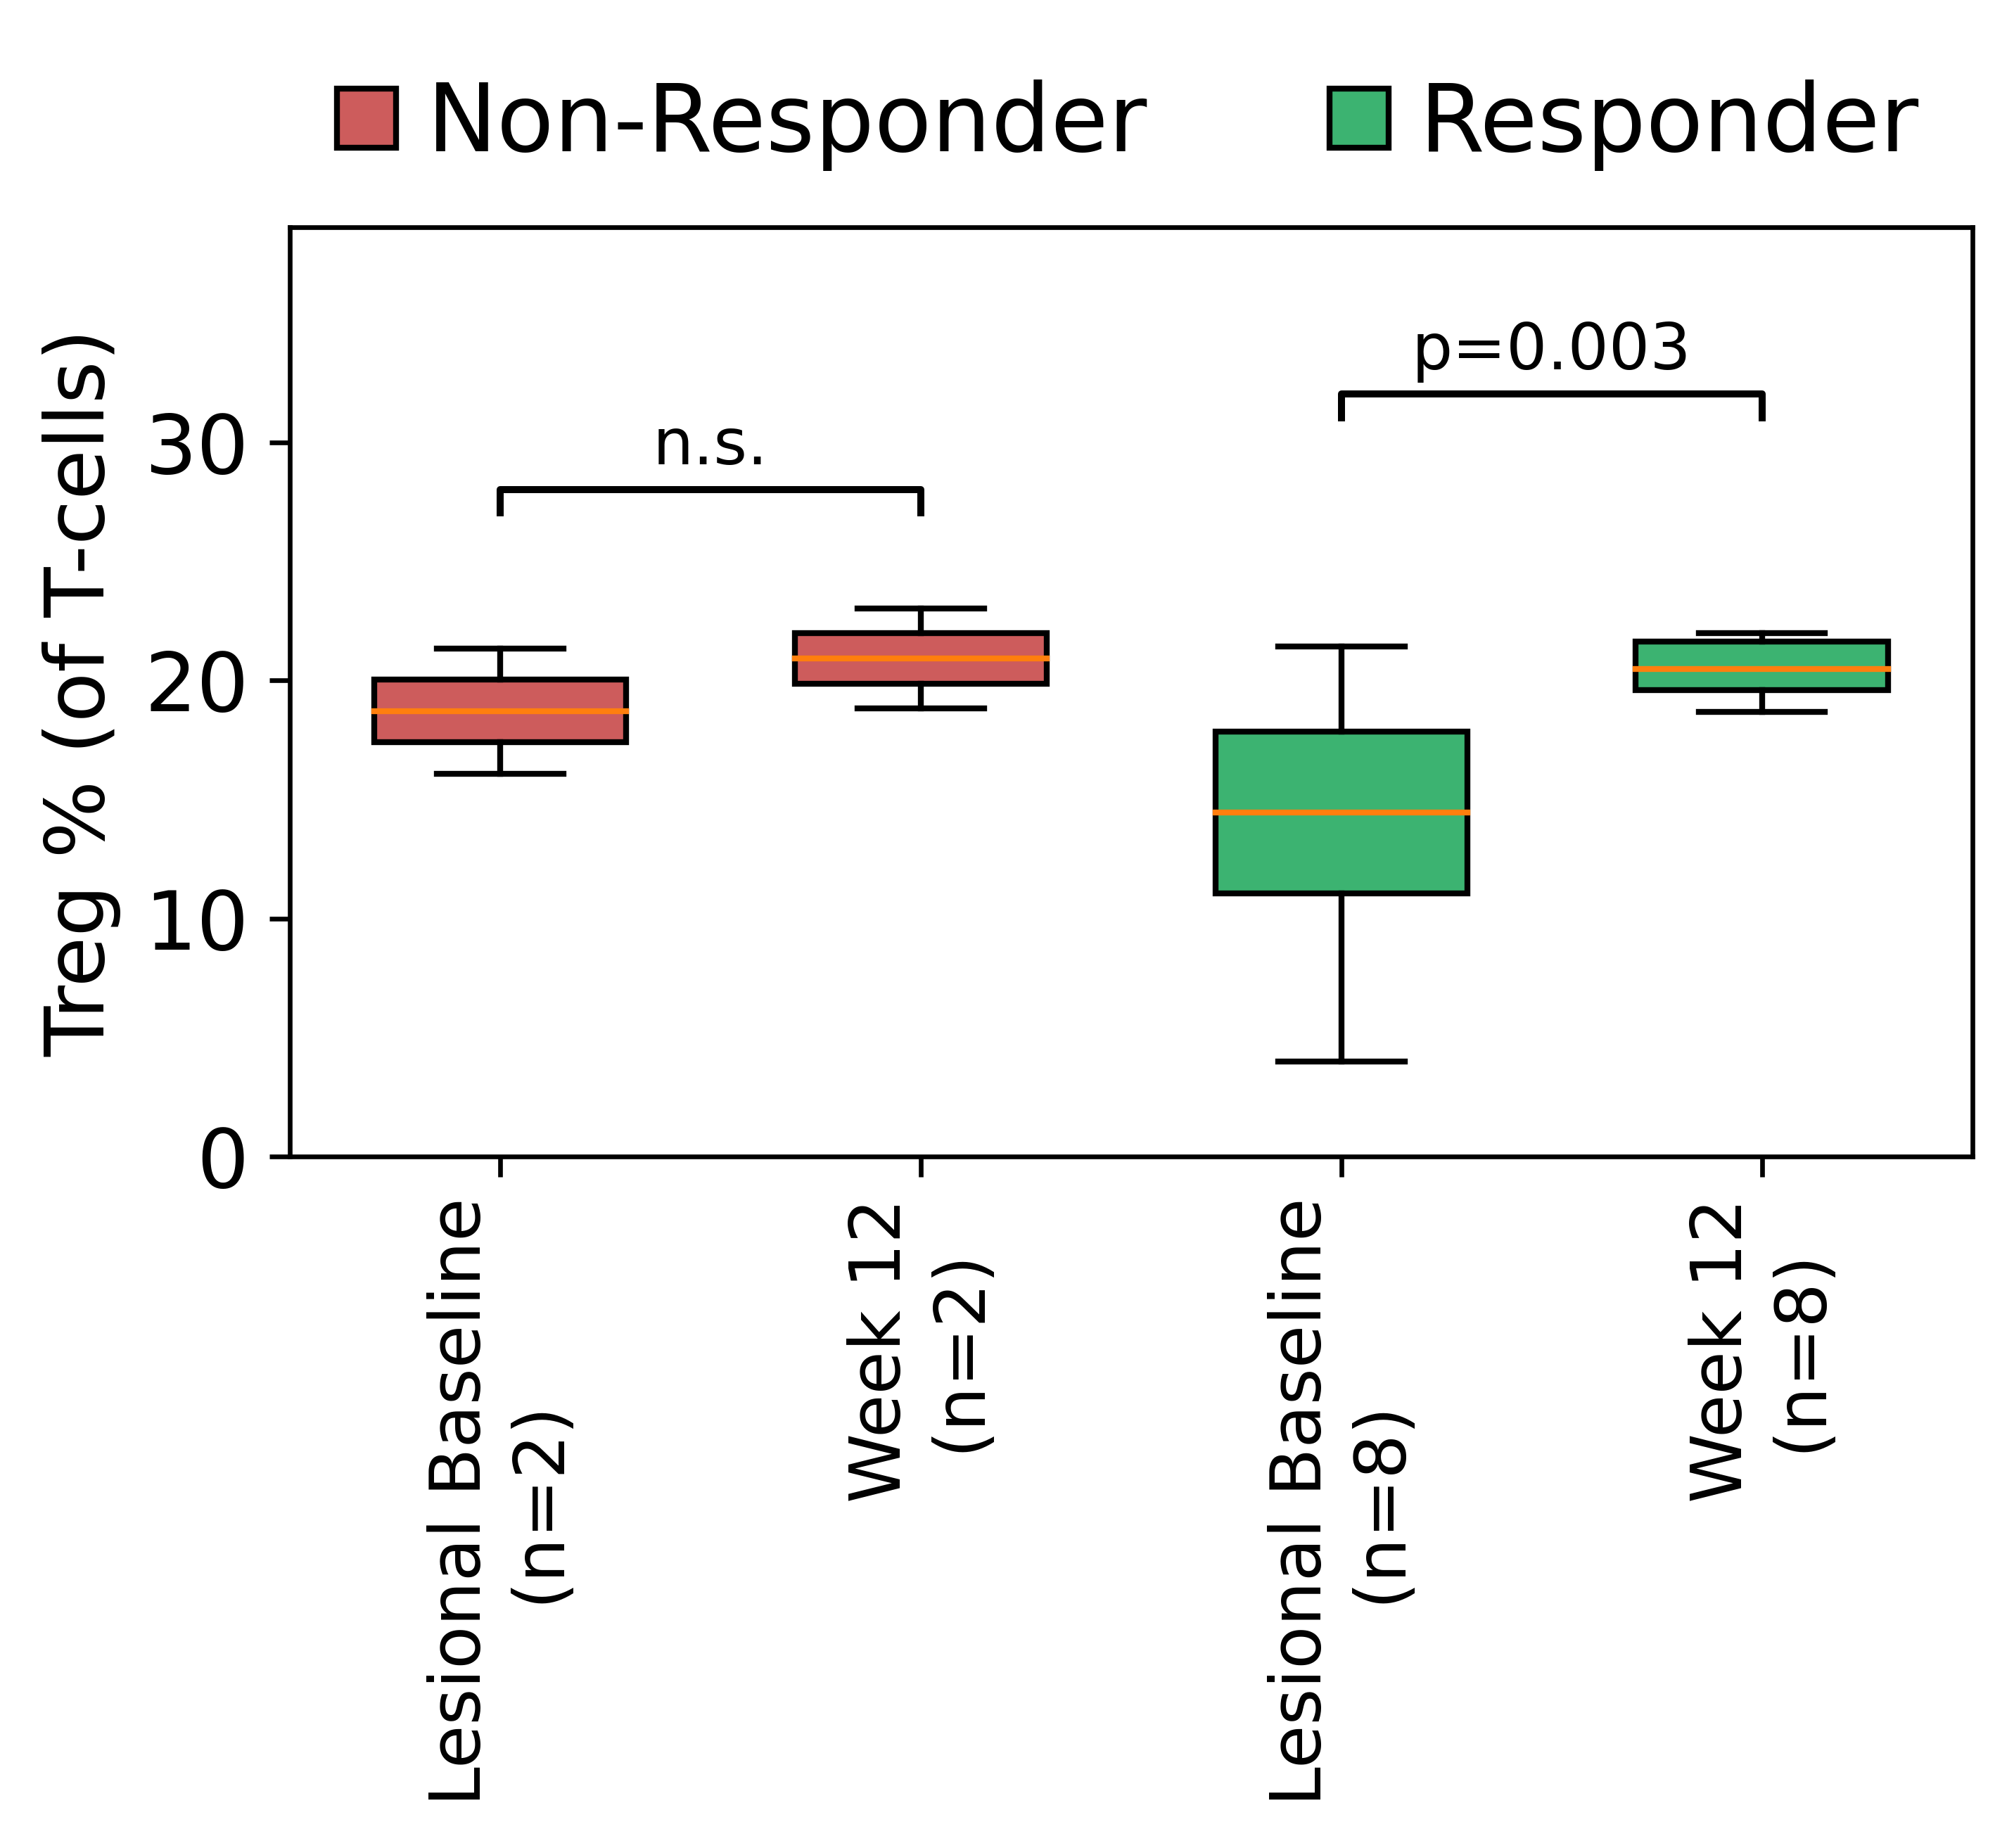

In [6]:
df_all = pd.DataFrame({
    "PatientID": adata_5k_baseline.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata_5k_baseline.obs["Timepoint2"].astype(str).values,
    "response": adata_5k_baseline.obs["response"].astype(float).values,
    "Cell_Type": adata_5k_baseline.obs["lvl4_annotation"].astype(str).values
})

df_T = df_all[df_all["Cell_Type"].str.startswith("T")].copy()
tot = df_T.groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Total_T")
trg = df_T[df_T["Cell_Type"] == "Treg"].groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Treg")
df_T = tot.merge(trg, how="left", on=["PatientID", "Timepoint2", "response"]).fillna(0)
df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_T"]
df_T["Response_Group"] = df_T["response"].apply(bin_response)
df_T = df_T.dropna(subset=["Response_Group"])

timepoints = ["Lesional Baseline", "Week 12"]
groups = ["Non-Responder", "Responder"]
colors = {"Responder": "#3CB371", "Non-Responder": "#CD5C5C"}

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
positions = []
data = []
labels = []
pos = 0
for g in groups:
    for t in timepoints:
        m = (df_T["Timepoint2"] == t) & (df_T["Response_Group"] == g)
        s = df_T.loc[m, "Percent"]
        data.append(s)
        labels.append(f"{t}\n(n={df_T.loc[m,'PatientID'].nunique()})")
        positions.append(pos)
        pos += 1

bp = ax.boxplot(data, positions=positions, patch_artist=True, widths=0.6, showfliers=False)
for i, b in enumerate(bp["boxes"]):
    b.set_facecolor(colors[groups[i // 2]])

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=90, fontsize=12)
ax.set_ylabel("Treg % (of T-cells)", fontsize=14)

handles = [plt.Line2D([0], [0], marker='s', lw=0, markerfacecolor=colors[g], markeredgecolor='black', markersize=10, label=g) for g in groups]
ax.legend(handles=handles, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2, fontsize=16)

y_off = 4
top = max(s.max() if len(s) else 0 for s in data) + y_off
for j, g in enumerate(groups):
    i1, i2 = j*2, j*2+1
    a, b = data[i1], data[i2]
    if len(a) and len(b):
        _, p = mannwhitneyu(a, b)
        x1, x2 = positions[i1], positions[i2]
        ax.plot([x1, x1, x2, x2], [top, top+1, top+1, top], lw=1.2, c='black')
        ax.text((x1+x2)/2, top+1.5, f"p={p:.3f}" if g=="Responder" else "n.s.", ha='center', va='bottom', fontsize=11)
        top += y_off

ax.set_ylim(0, top + y_off)
ax.grid(False)
plt.tight_layout()
plt.savefig("figures/Treg_fraction_Tcells_with_stats_and_donors.pdf", dpi=300, bbox_inches="tight")
plt.show()

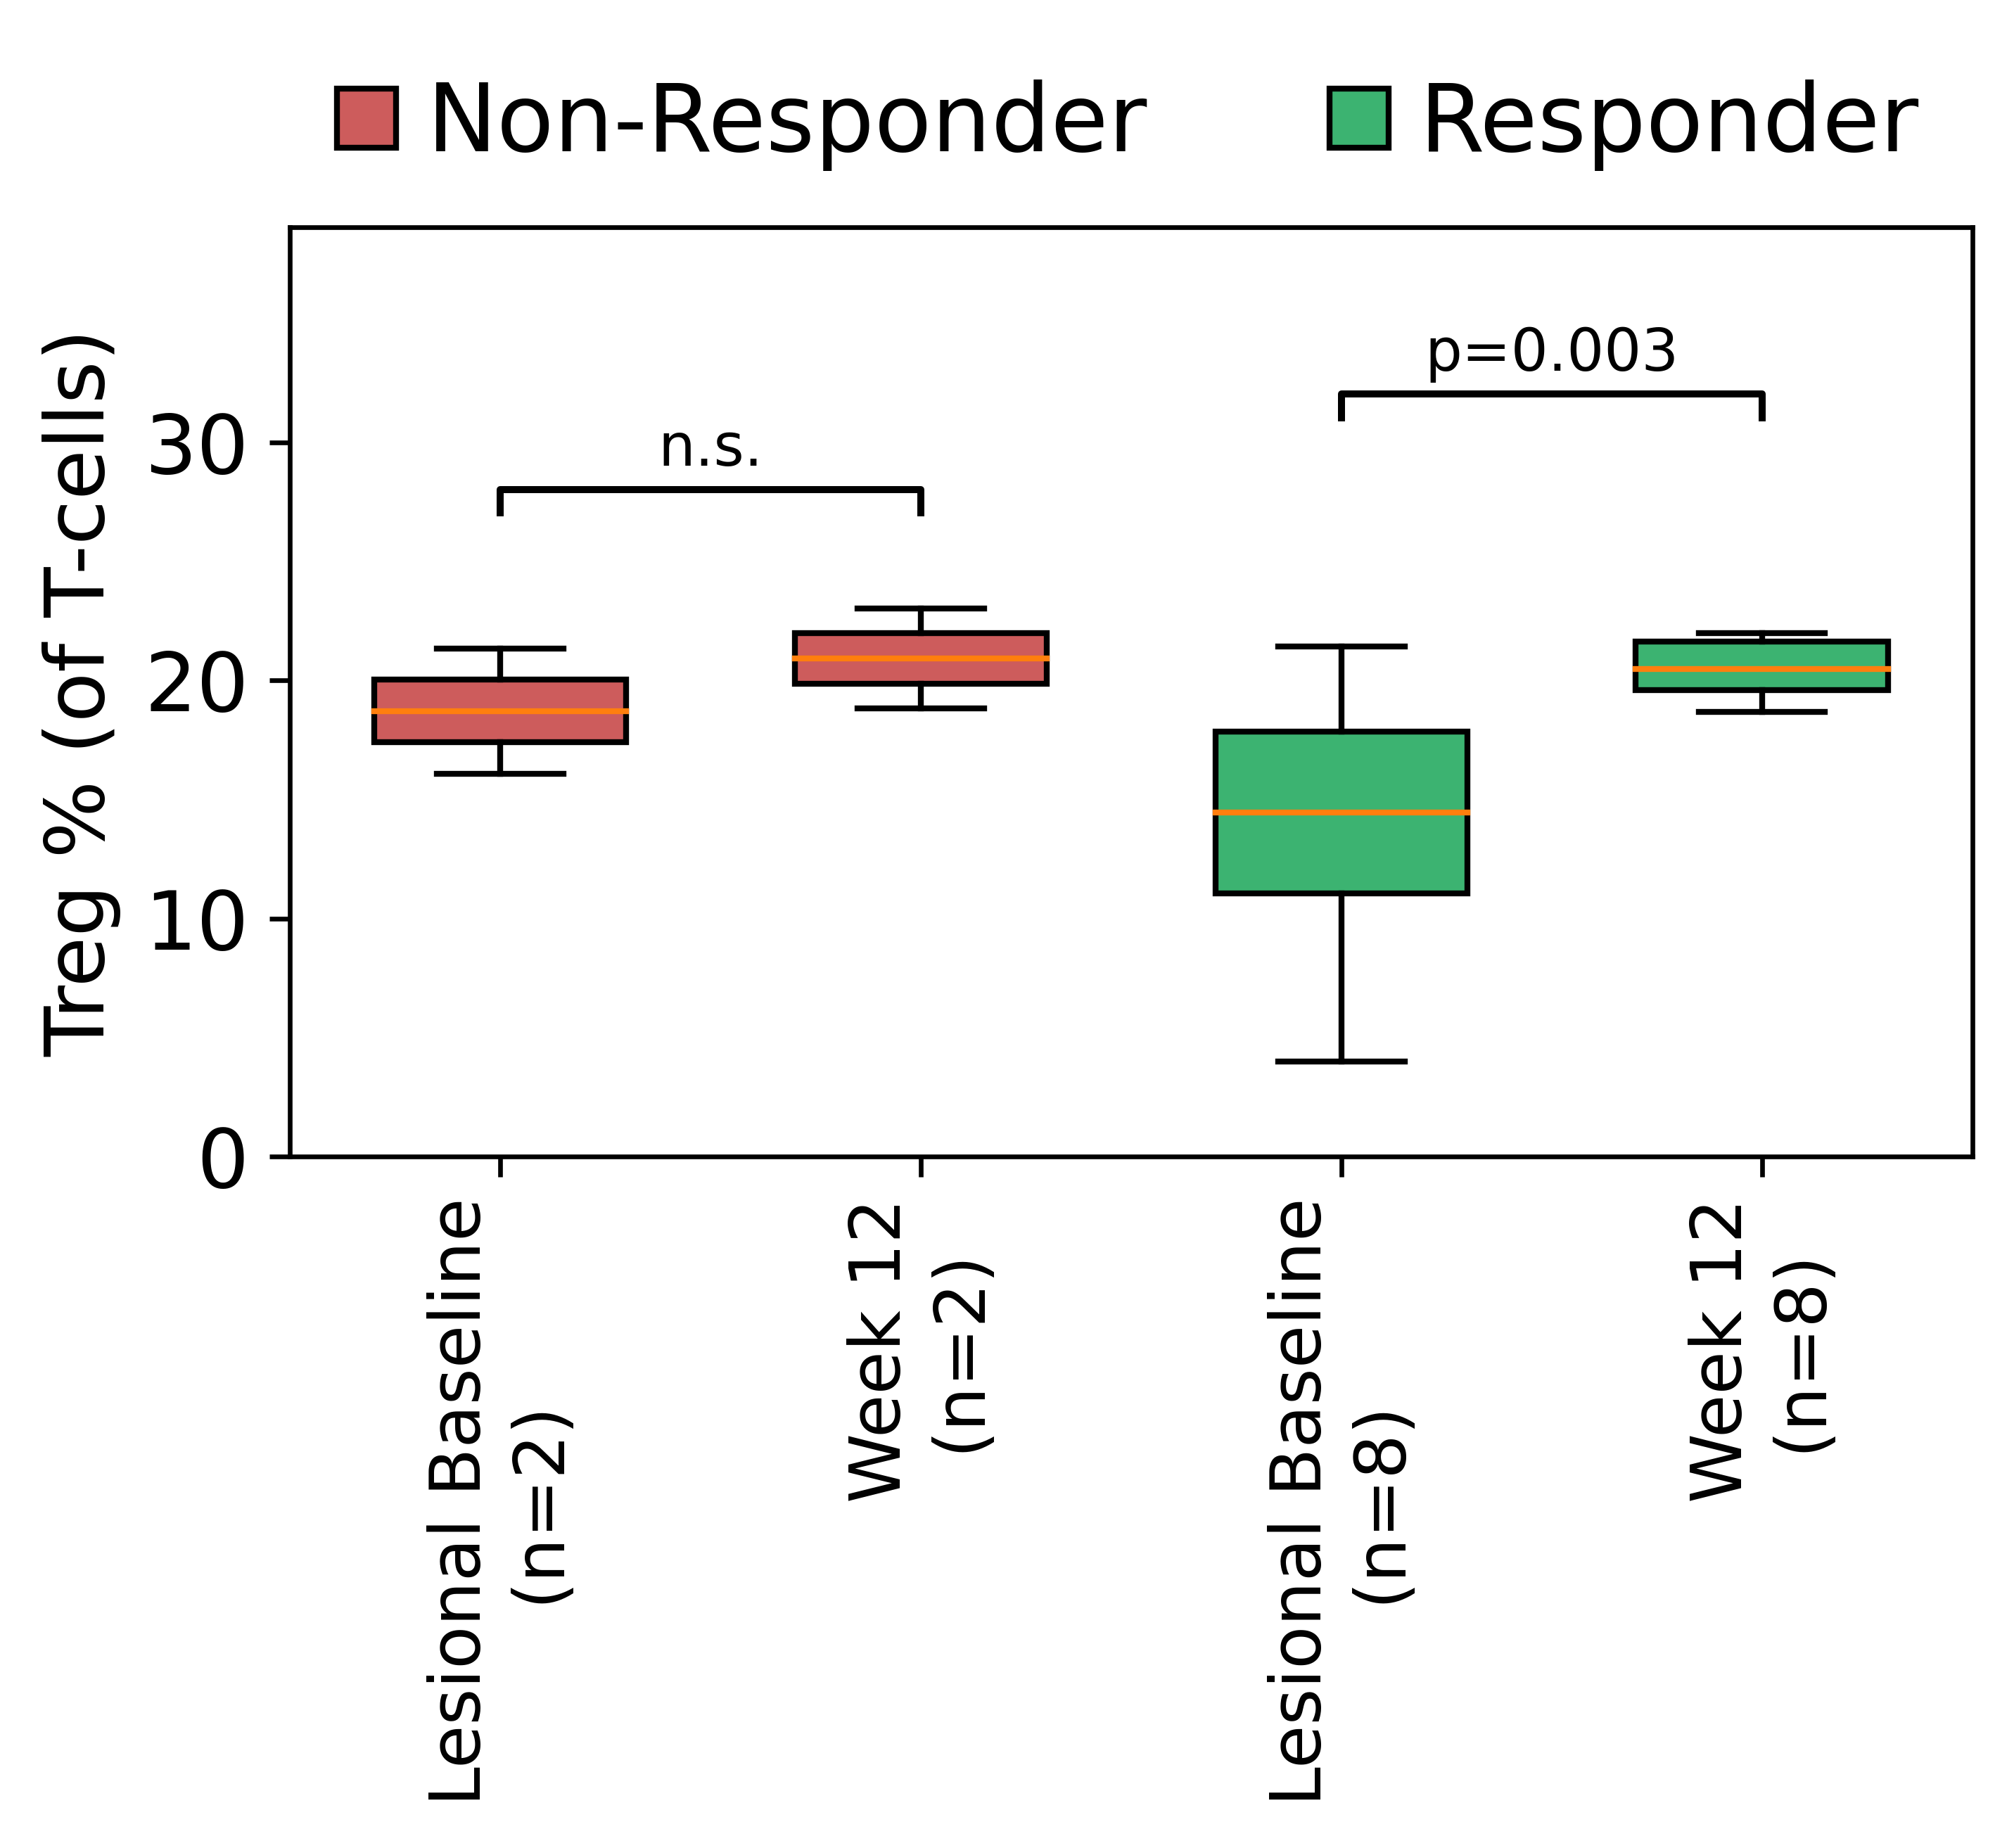

In [7]:

df_T = df_all[df_all["Cell_Type"].str.startswith("T")].copy()

tot = (
    df_T.groupby(["PatientID", "Timepoint2", "response"])
        .size().reset_index(name="Total_T")
)
trg = (
    df_T[df_T["Cell_Type"] == "Treg"]
        .groupby(["PatientID", "Timepoint2", "response"])
        .size().reset_index(name="Treg_Count")
)
df_T = tot.merge(trg, how="left",
                 on=["PatientID", "Timepoint2", "response"])
df_T["Treg_Count"] = df_T["Treg_Count"].fillna(0)
df_T["Percent"]    = 100 * df_T["Treg_Count"] / df_T["Total_T"]

df_T["Response_Group"] = df_T["response"].apply(
    lambda r: "Non-Responder" if r < 10 else
              "Responder"     if r > 50 else np.nan)
df_T = df_T.dropna(subset=["Response_Group"])


timepoints      = ["Lesional Baseline", "Week 12"]
response_groups = ["Non-Responder", "Responder"]
colors          = {"Responder": "#3CB371", "Non-Responder": "#CD5C5C"}

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

positions, data, labels = [], [], []
xpos = 0
for rg in response_groups:
    for tp in timepoints:
        mask    = (df_T["Timepoint2"] == tp) & (df_T["Response_Group"] == rg)
        subset  = df_T.loc[mask, "Percent"]
        n_don   = df_T.loc[mask, "PatientID"].nunique()
        data.append(subset)
        labels.append(f"{tp}\n(n={n_don})")
        positions.append(xpos)
        xpos += 1

bp = ax.boxplot(
    data, positions=positions, widths=0.6,
    patch_artist=True, showfliers=False)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(colors[response_groups[i // 2]])

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=90, fontsize=12)
ax.set_ylabel("Treg % (of T-cells)", fontsize=14)

handles = [plt.Line2D([0], [0], marker='s', lw=0,
           markerfacecolor=colors[g], markeredgecolor='black',
           markersize=10, label=g) for g in response_groups]
ax.legend(handles=handles, frameon=False,
          loc="upper center", bbox_to_anchor=(0.5, 1.25), ncol=2, fontsize=16)

y_offset = 4
stat_y   = max(sub.max() if len(sub) else 0 for sub in data) + y_offset

for j, rg in enumerate(response_groups):
    idx_bl, idx_w12 = j*2, j*2 + 1
    y1, y2 = data[idx_bl], data[idx_w12]
    if len(y1) and len(y2):
        _, p = mannwhitneyu(y1, y2, alternative="two-sided")
        label = "n.s." if rg == "Non-Responder" and p >0.05 else f"p={p:.3f}"
        x1, x2 = positions[idx_bl], positions[idx_w12]
        ax.plot([x1, x1, x2, x2],
                [stat_y, stat_y+1, stat_y+1, stat_y],
                lw=1.2, c='black')
        ax.text((x1 + x2) / 2, stat_y + 1.5, label,
                ha='center', va='bottom', fontsize=10)
        stat_y += y_offset

ax.set_ylim(0, stat_y + y_offset)
ax.grid(False)
plt.tight_layout()
plt.savefig("figures/Treg_fraction_Tcells_with_pvalues.pdf",
            dpi=300, bbox_inches="tight")
plt.show()